In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
from contact_map import ContactFrequency, ContactDifference, AtomMismatchedContactDifference
import scipy.stats as st
from scipy.stats import ttest_ind
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import mdtraj as md

In [3]:
minA = 1
maxA = 58
minB = 60
maxB = 76
traj_combined_list = []

# AbpSH3 ArkA17 No salt 

In [4]:
traj_list = ["abp1-arka_1_stripped.mdcrd", "abp1-arka_2_stripped.mdcrd", "abp1-arka_3_stripped.mdcrd", "abp1-arka_4_stripped.mdcrd", "abp1-arka_5_stripped.mdcrd", 
          "abp1-arka_6_stripped.mdcrd", "abp1-arka_7_stripped.mdcrd", "abp1-arka_8_stripped.mdcrd", "abp1-arka_9_stripped.mdcrd", "abp1-arka_10_stripped.mdcrd"]

traj_no_salt_new = []
for suffix in tqdm(traj_list):
    traj_no_salt_new.append(md.load_netcdf("/data/oonwuzul/abp1-arka17_bound/no_salt/analysis/mdcrd/prod_stripped/" + suffix, 
                          top="/data/aadkins/SH3/abp1-arka17/abp1-arka_gas.prmtop", stride=300))

  0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
traj_no_salt_new[0]

<mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f1334140>

In [6]:
topology = traj_no_salt_new[0].topology
topology

<mdtraj.Topology with 1 chains, 76 residues, 1190 atoms, 1209 bonds at 0x1553f12c9430>

In [7]:
traj_no_salt_new

[<mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f1334140>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f0d98830>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f133bef0>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f0d7fef0>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f0ef2ab0>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f1008230>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f100a570>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f0f21400>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f0f213d0>,
 <mdtraj.Trajectory with 800 frames, 1190 atoms, 76 residues, without unitcells at 0x155552141070>]

In [8]:
import sys
sys.getsizeof(traj_no_salt_new.copy())

136

In [9]:
traj_no_salt_combined = md.join(traj_no_salt_new)

In [10]:
# cat /proc/sys/vm/overcommit_memory

In [11]:
traj_no_salt_combined

<mdtraj.Trajectory with 8000 frames, 1190 atoms, 76 residues, without unitcells at 0x1553f04d7da0>

In [12]:
traj_no_salt_combined_contacts = ContactFrequency(traj_no_salt_combined)

<timed exec>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


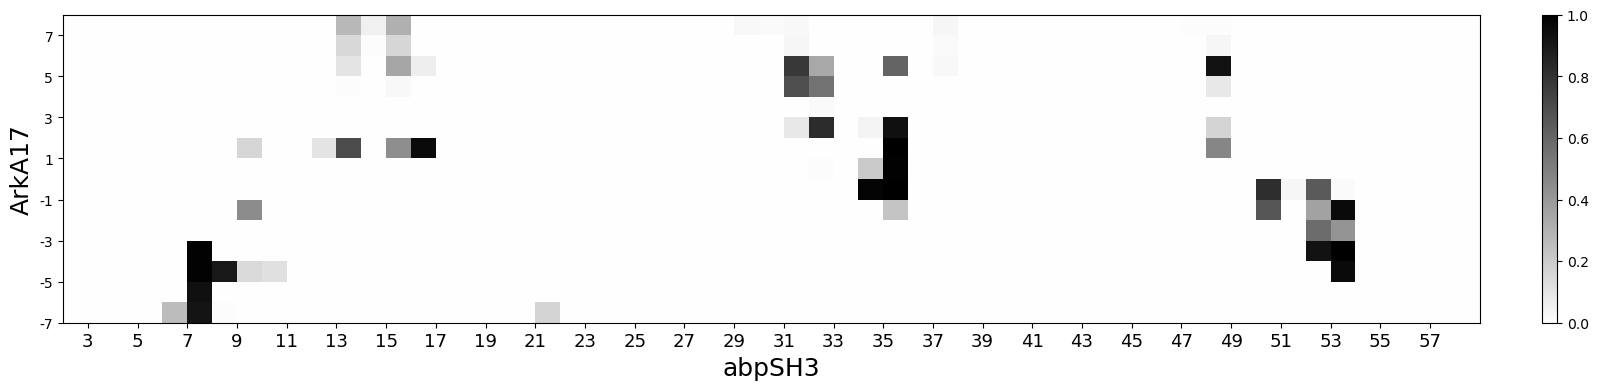

CPU times: user 654 ms, sys: 2.99 ms, total: 657 ms
Wall time: 658 ms


In [13]:
%%time
map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","white","black"])

fig, ax = traj_no_salt_combined_contacts.residue_contacts.plot (nrows=1, ncols=1, figsize=(20, 4), cmap= map)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)

my_yticks =['-7','-5','-3','-1','1','3','5','7']
current_yticks = [60, 62, 64, 66, 68, 70, 72, 74]
ax.set_xticks 
ax.set_yticks 

#plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
#plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)    
plt.xticks(current_xticks,my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)

ax.set_xticks 
ax.set_yticks 
ax.set_yticklabels(my_yticks)

ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB-1)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA17", fontsize=18)
plt.show()
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

In [14]:
type(traj_no_salt_combined_contacts.residue_contacts)

contact_map.contact_count.ContactCount

# AbpSH3 ArkA17 Salt 

In [15]:
traj_list_salt = ["abp1-arka_highsalt_stripped_with_ions_1.mdcrd", "abp1-arka_highsalt_stripped_with_ions_2.mdcrd", "abp1-arka_highsalt_stripped_with_ions_3.mdcrd", "abp1-arka_highsalt_stripped_with_ions_4.mdcrd", "abp1-arka_highsalt_stripped_with_ions_5.mdcrd", 
          "abp1-arka_highsalt_stripped_with_ions_6.mdcrd", "abp1-arka_highsalt_stripped_with_ions_7.mdcrd", "abp1-arka_highsalt_stripped_with_ions_8.mdcrd", "abp1-arka_highsalt_stripped_with_ions_9.mdcrd", "abp1-arka_highsalt_stripped_with_ions_10.mdcrd"]

traj_new_salt = []
for suffix in traj_list_salt:
    traj_new_salt.append(md.load_netcdf("/data/oonwuzul/abp1-arka17_bound/salt/abp1-arka17_800mM_salt/mdcrd/prod_stripped/" + suffix, 
                          top="/data/oonwuzul/abp1-arka17_bound/salt/abp1-arka17_800mM_salt/prmtop/stripped_with_ions.prmtop", stride=300 ))

In [16]:
topology = md.join(traj_new_salt).topology
df = topology.to_dataframe()[0]
topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])

/tmp/ipykernel_3566629/3525368574.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])


In [17]:
traj_combined_salt = md.join(traj_new_salt)

In [18]:
traj_combined_contacts_salt = ContactFrequency(traj_combined_salt)

In [19]:
def get_window(diffy):
    window = pd.DataFrame(diffy.residue_contacts.df.iloc[:maxB, :maxB]).fillna(0).iloc[minB-1:maxB, minA-1:maxA]
    return window.reindex(index=window.index[::-1])

In [20]:
diffy_salt = []
diffy_no_salt = []
for i in tqdm(range(min(len(traj_new_salt), len(traj_no_salt_new)))):
    #diffy.append(AtomMismatchedContactDifference(salt_con, no_salt_con))
    diffy_salt.append(ContactFrequency(traj_new_salt[i]))
    diffy_no_salt.append(ContactFrequency(traj_no_salt_new[i]))

  0%|          | 0/10 [00:00<?, ?it/s]

In [21]:
def ci_intersect(bs1, bs2):
    high1 = bs1.confidence_interval.high
    high2 = bs1.confidence_interval.high
    low1 = bs2.confidence_interval.low
    low2 = bs2.confidence_interval.low
    
    if low1 < low2:
        return high1 < low2
    else:
        return high2 < low1

In [22]:
def bootstrap(data1, data2, numsample=int(1e5)):
    _ = len(data1)
    len_2 = len(data2)
    
    data = np.concatenate([data1, data2])

    diff = abs(np.mean(data[:len_2]) - np.mean(data[len_2:]))
    
    diff_samples = np.zeros(numsample)
    diff_samples_larger = 0

    for sample in range(len(diff_samples)):
        random_groups = np.random.permutation(data)
        
        diff_samples[sample] = np.mean(random_groups[:len_2]) - np.mean(random_groups[len_2:])
        
        if diff_samples[sample] >= diff:
            diff_samples_larger += 1

    return (1 + diff_samples_larger) / (numsample + 1)

In [23]:
import scipy.stats

diff_df_salt = [get_window(diff) for diff in diffy_salt]
diff_df_no_salt = [get_window(diff) for diff in diffy_no_salt]
significant = diff_df_salt[0].copy().sparse.to_dense()

# p_val_df = diff_df_no_salt[0].copy(deep=True)
p_val_df = pd.DataFrame().reindex_like(diff_df_no_salt[0])

for col in tqdm(range(len(diff_df_salt[0].columns))):
    for row in range(len(diff_df_salt[0].index)):
        salt_data = [df.iloc[row, col] for df in diff_df_salt]
#         print(f"salty daty: ",row, col)
        no_salt_data = [df.iloc[row, col] for df in diff_df_no_salt]
        if all(v == 0 for v in no_salt_data) and all(v == 0 for v in salt_data):
            significant.iloc[row, col] = 1
        else:
            pval = bootstrap(salt_data, no_salt_data)
            significant.iloc[row, col] = pval
# p_val_df

  0%|          | 0/58 [00:00<?, ?it/s]

In [24]:
len(diff_df_salt[0].columns)

58

In [25]:
 print(significant.iloc[:15,8 ])  # Display all available rows of column ten since there are only 9 rows

75    0.236838
74    1.000000
73    1.000000
72    0.502825
71    1.000000
70    1.000000
69    1.000000
68    0.308717
67    1.000000
66    0.411486
65    0.292127
64    1.000000
63    1.000000
62    0.067999
61    1.000000
Name: 8, dtype: float64


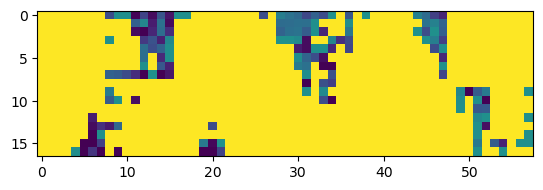

In [26]:
plt.imshow(np.array(significant.values.tolist()))

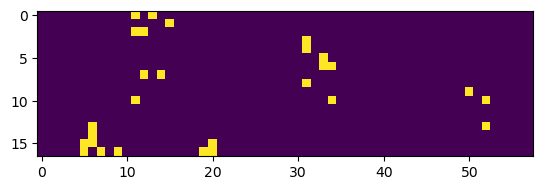

In [27]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

In [28]:
np.where(significant < 0.05)

(array([ 0,  0,  1,  2,  2,  3,  4,  5,  6,  6,  7,  7,  8,  9, 10, 10, 10,
        13, 13, 14, 15, 15, 15, 16, 16, 16, 16, 16]),
 array([11, 13, 15, 11, 12, 31, 31, 33, 33, 34, 12, 14, 31, 50, 11, 34, 52,
         6, 52,  6,  5,  6, 20,  5,  7,  9, 19, 20]))

In [29]:
num_values = len(significant) * len(significant.columns) # following the Bonferroni Method
sig = np.array((significant < (0.05/num_values)).values.tolist())

In [30]:
np.where(sig)

(array([ 8, 15, 15, 16, 16, 16]), array([31,  5,  6,  7, 19, 20]))

In [31]:
p_val_df[(p_val_df < 0.05)]
#list(zip(list(np.argwhere(p_val_df.to_numpy())), list(np.where(p_val_df.to_numpy()))))

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
#bootstrap(traj)

In [33]:
dir(traj_combined_contacts_salt)
#traj_combined_contacts_salt.to_dict()

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__weakref__',
 '_all_atoms',
 '_all_residues',
 '_atom_contacts',
 '_build_contact_map',
 '_check_compatibility',
 '_class_use_atom_slice',
 '_contact_map',
 '_cutoff',
 '_deserialize_contact_counter',
 '_deserialize_topology',
 '_haystack',
 '_n_frames',
 '_n_neighbors_ignored',
 '_pending_dep_msg',
 '_query',
 '_residue_contacts',
 '_residue_ignore_atom_idxs',
 '_serialize_contact_counter',
 '_serialize_topology',
 '_set_atom_slice',
 '_topology',
 '_use_atom_slice',
 'add_contact_frequency',
 'all_atoms',
 'atom_contacts',
 'contacts',
 'cutoff',
 'from_contacts',
 'from_dict',
 'from_file',
 'from_json',

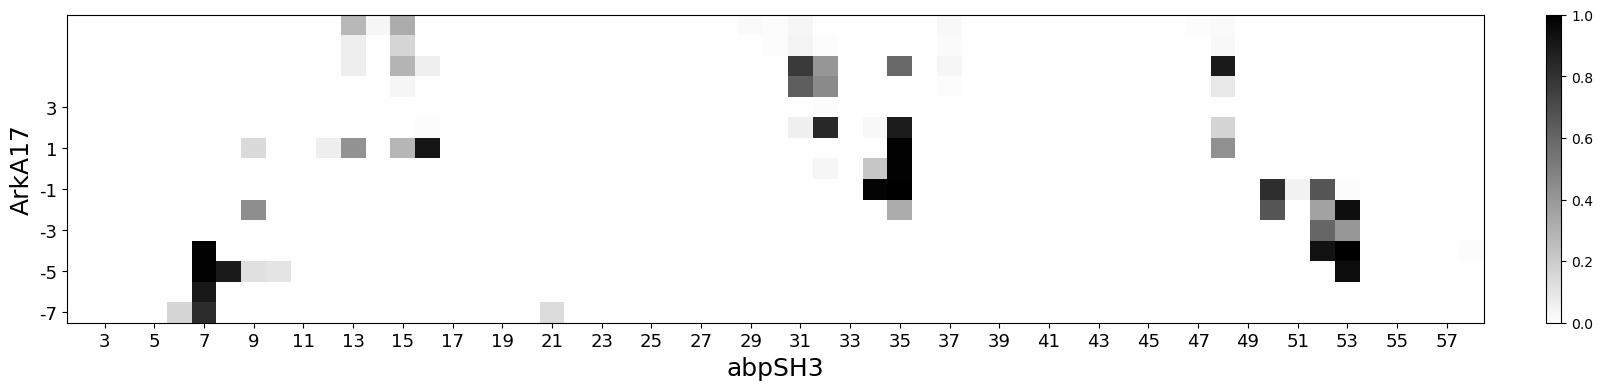

CPU times: user 16.5 s, sys: 118 ms, total: 16.6 s
Wall time: 16.6 s


In [34]:
%%time
fig, ax = traj_combined_contacts_salt.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap= map)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = ['-7','-5','-3','-1','1','3']
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
   # current_yticks.append(y+0.5)
    #my_yticks.append(y)
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 

#plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)
ax.set_yticklabels(my_yticks, fontsize=13)
ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB-1)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA17", fontsize=18)

plt.show()
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_unphosphorylated.png', bbox_inches = "tight", dpi= 2000)


# ArkA12_Bound_Contact_Difference

In [35]:
diff = AtomMismatchedContactDifference(traj_no_salt_combined_contacts, traj_combined_contacts_salt)

In [36]:
traj_no_salt_combined_contacts.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,66,67,68,69,70,71,72,73,74,75
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.00025,0.00225,NaN,NaN,NaN,NaN,NaN,0.02,0.076125
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.660125,0.96,NaN,NaN,NaN,NaN,NaN,0.010375
73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.012875,0.5,0.6155,0.815125,NaN,NaN,NaN,NaN,NaN
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000375,0.066125,0.013125,0.062375,0.02,NaN,NaN,NaN,NaN


In [37]:
traj_combined_contacts_salt.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,195,196,197,198,199,200,201,202,203,204
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002333,0.001,0.002,0.001667,0.003,0.002333,0.002667,0.001667,0.002667,0.001
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.003,0.001333,0.004,0.000667,0.001667,0.003333,0.003,0.003,0.002667,0.001
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000333,0.000333,0.000333,NaN,NaN,0.000333,0.000333,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.002333,0.003333,NaN,NaN,NaN,0.000333,NaN,0.000667,NaN,0.001,...,0.000333,0.000333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000333
201,0.002667,0.003,NaN,NaN,NaN,NaN,NaN,0.000667,NaN,0.001333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000333
202,0.001667,0.003,NaN,0.000333,NaN,0.001333,0.001333,0.001333,NaN,0.001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203,0.002667,0.002667,NaN,0.000333,NaN,0.000667,NaN,NaN,NaN,0.000333,...,NaN,0.000667,0.000333,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# current_xticks

[(3, 21), (3, 56), (3, 57), (8, 11), (9, 15), (10, 13), (10, 16), (11, 8), (11, 15), (12, 15), (12, 68), (13, 10), (14, 47), (14, 68), (15, 9), (15, 11), (15, 12), (16, 10), (16, 38), (20, 59), (21, 3), (38, 16), (47, 14), (54, 57), (56, 3), (57, 3), (57, 54), (59, 20), (68, 12), (68, 14)]


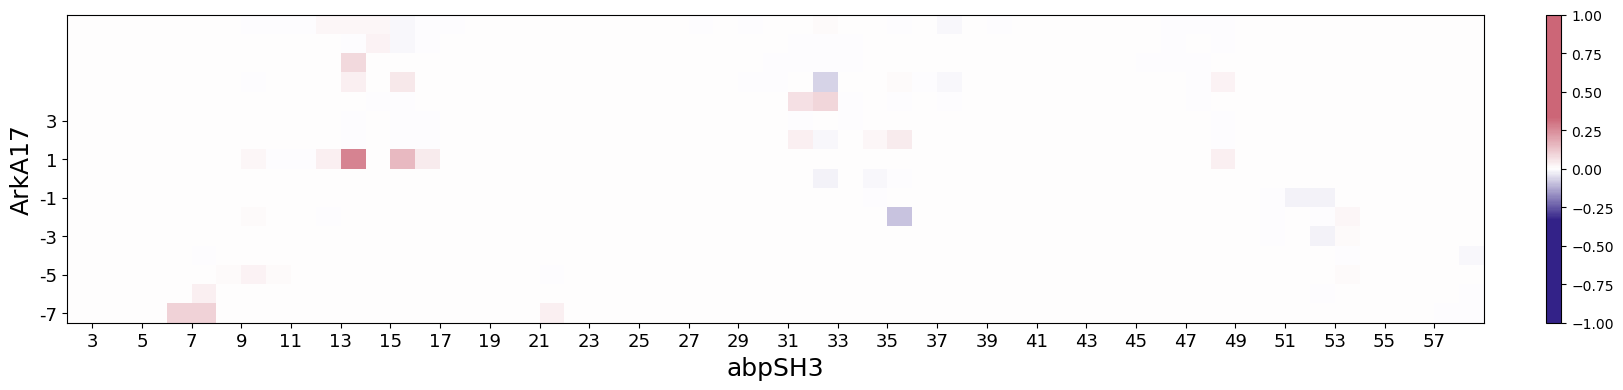

CPU times: user 628 ms, sys: 4.99 ms, total: 633 ms
Wall time: 633 ms


In [39]:
%%time
map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = map_1) 
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = my_yticks = ['-7','-5','-3','-1','1','3']
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)
    
args = list(zip(*(np.abs(diff.residue_contacts.df.to_numpy()) > 0.1).nonzero()))
print(args)

#for x, y in args
    #plt.text(x + 0.5, y + 0.5, ':)', horizontalalignment='center', verticalalignment='center', size=12)
    
plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)

ax.set_yticklabels(my_yticks)

ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA17", fontsize=18)
#plt.title('ArkA12_bound_contact_difference_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_diff.png', bbox_inches = "tight", dpi= 2000)
plt.show()

In [40]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
75,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.236838,0.496035,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
74,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
73,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
72,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.502825,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
71,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
70,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
69,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
68,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.308717,0.290427,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
67,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
66,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.411486,1.000000,...,1.0,0.453715,0.00183,0.292427,0.406826,1.000000,1.000000,1.0,1.000000,0.501335


In [41]:
diff.residue_contacts.df.iloc[minB-1:maxB, minA-1:maxA]



,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
59,NaN,NaN,NaN,NaN,0.000042,0.084875,0.029792,0.054917,NaN,0.000875,...,NaN,NaN,NaN,0.000125,NaN,NaN,-0.000208,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,0.097958,0.094458,0.002208,NaN,NaN,...,NaN,NaN,NaN,0.000417,NaN,0.000292,0.000542,NaN,-0.000333,-0.00575
61,NaN,NaN,NaN,NaN,NaN,NaN,0.03375,0.000125,NaN,NaN,...,NaN,NaN,NaN,-0.000208,NaN,NaN,NaN,NaN,NaN,-0.000333
62,NaN,NaN,NaN,NaN,NaN,NaN,0.004125,0.008667,0.024667,0.012875,...,NaN,NaN,NaN,0.000125,0.009833,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,-0.004167,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000958,-0.000042,NaN,NaN,NaN,NaN,-0.011542
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.000083,NaN,-0.021417,0.013667,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012625,0.000125,...,NaN,-0.002583,NaN,-0.000625,0.016458,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000792,NaN,...,NaN,-0.002375,-0.017458,-0.018042,0.003917,NaN,NaN,NaN,NaN,0.000125
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021542,-0.000375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


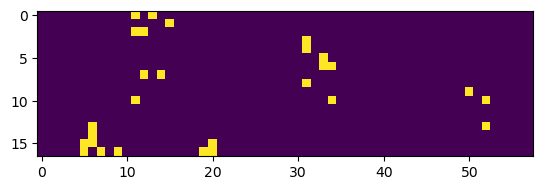

In [42]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

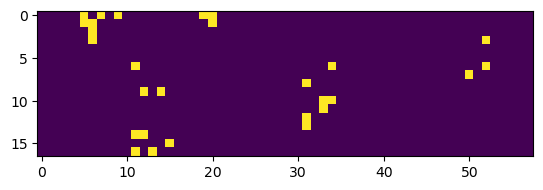

In [43]:
# Flip rows of significant dataframe to match with correct rows of diff dataframe
significant_rev = significant.iloc[::-1]
plt.imshow(np.array((significant_rev < 0.05).values.tolist()))

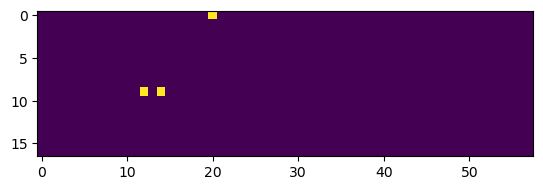

In [44]:
plt.imshow(np.array((diff.residue_contacts.df.iloc[minB-1:maxB, minA-1:maxA] > 0.1).values.tolist()))

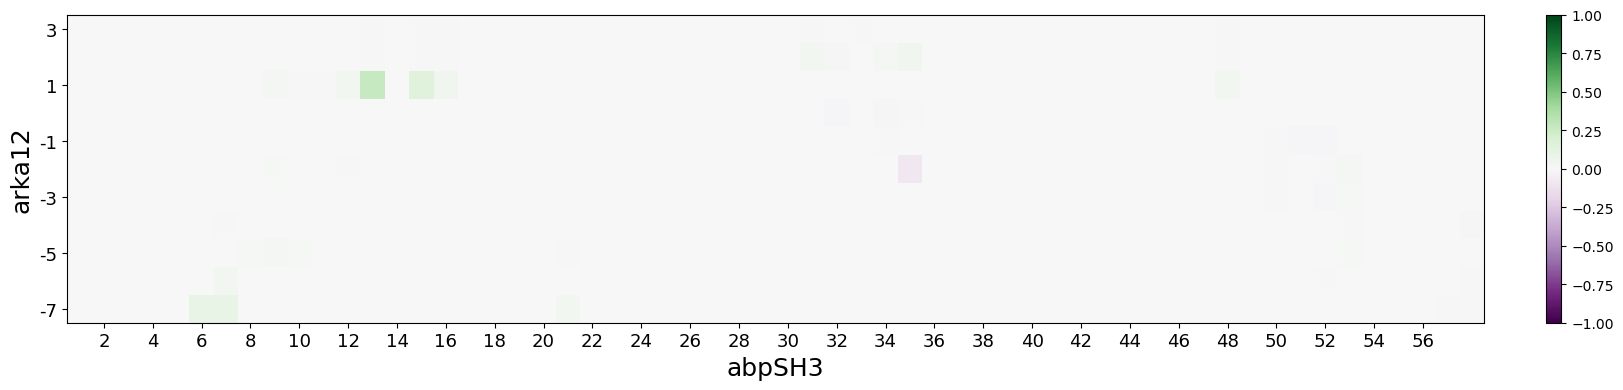

CPU times: user 605 ms, sys: 5 ms, total: 610 ms
Wall time: 610 ms


In [45]:
%%time
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = "PRGn") 
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []

for x in range(int(minA)-1, int(maxA), 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = my_yticks = ['-7','-5','-3','-1','1','3']
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)
    
plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 

ax.set_yticklabels(my_yticks)

ax.set_xlim(0,58)
ax.set_ylim(60,71)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("arka12", fontsize=18)
#plt.title('ArkA12_bound_contact_difference_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_diff.png', bbox_inches = "tight", dpi= 2000)
plt.show()

In [46]:

contact_diff_data = diff.residue_contacts.df

#Display the DataFrame
#print(sorted(list(set(list(contact_diff_df['Residue_B'])))))
#dir(contact_diff_data)
#contact_diff_data
#fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = "PRGn") 
window = (contact_diff_data.iloc[:72, :72]).fillna(0).iloc[60:72, 0:58]
window = window.reindex(index=window.index[::-1])

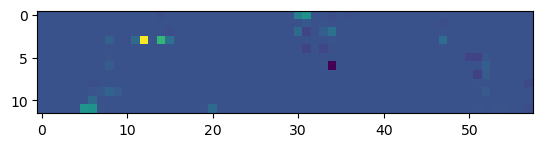

In [47]:

plt.imshow(window)


In [48]:
window

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68,0,0,0,0,0,0,0,0,0.021542,-0.000375,...,0,0,0,0,0,0,0,0,0,0
67,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
66,0,0,0,0,0,0,0,0,0.000792,0,...,0,-0.002375,-0.017458,-0.018042,0.003917,0,0,0,0,0.000125
65,0,0,0,0,0,0,0,0,0.012625,0.000125,...,0,-0.002583,0,-0.000625,0.016458,0,0,0,0,0
64,0,0,0,0,0,0,0,0,0,0,...,0,-0.000083,0,-0.021417,0.013667,0,0,0,0,0
63,0,0,0,0,0,0,-0.004167,0,0,0,...,0,0,0,0.000958,-0.000042,0,0,0,0,-0.011542
62,0,0,0,0,0,0,0.004125,0.008667,0.024667,0.012875,...,0,0,0,0.000125,0.009833,0,0,0,0,0


In [49]:
# Inspect the attributes and methods of the diff.residue_contacts object
print(dir(diff.residue_contacts))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_number_of_pixels', '_counter', '_object_f', 'counter', 'df', 'filter', 'most_common', 'most_common_idx', 'n_x', 'n_y', 'plot', 'plot_axes', 'sparse_matrix']


In [50]:
# understanding the attributes of the ContactFrequency objects
print(dir(traj_no_salt_combined_contacts))
print(dir(traj_combined_contacts_salt))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_all_atoms', '_all_residues', '_atom_contacts', '_build_contact_map', '_check_compatibility', '_class_use_atom_slice', '_contact_map', '_cutoff', '_deserialize_contact_counter', '_deserialize_topology', '_haystack', '_n_frames', '_n_neighbors_ignored', '_pending_dep_msg', '_query', '_residue_contacts', '_residue_ignore_atom_idxs', '_serialize_contact_counter', '_serialize_topology', '_set_atom_slice', '_topology', '_use_atom_slice', 'add_contact_frequency', 'all_atoms', 'atom_contacts', 'contacts', 'cutoff', 'from_contacts', 'from_dict', 'from_file', 'from_json', 'haystack', 'haystack_residue_range', 'haystack_residues'

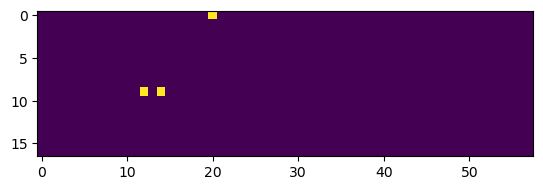

In [51]:

#np.array((significant[significant < 0.05]).values.tolist())
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)
salt = traj_combined_contacts_salt.residue_contacts.df.iloc[minB-1:maxB,minA-1:maxA]
no_salt = traj_no_salt_combined_contacts.residue_contacts.df.iloc[minB-1:maxB,minA-1:maxA]
difference = diff.residue_contacts.df.iloc[minB-1:maxB,minA-1:maxA]

perc_diff = ((difference.abs())/((salt + no_salt)/2))*100
plt.imshow(np.array((difference.abs() > 0.1).values.tolist()))


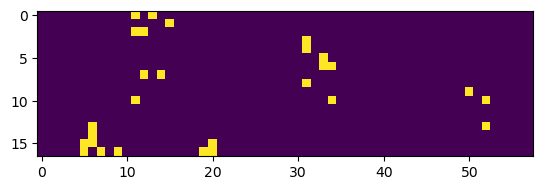

In [52]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

In [53]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
75,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.236838,0.496035,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
74,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
73,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
72,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.502825,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
71,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
70,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
69,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
68,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.308717,0.290427,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
67,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
66,1.0,1.0,1.0,1.0,1.000000,1.00000,1.000000,1.000000,0.411486,1.000000,...,1.0,0.453715,0.00183,0.292427,0.406826,1.000000,1.000000,1.0,1.000000,0.501335


Current dimensions: 6.4 x 4.8 inches
New dimensions: 7 x 5.249999999999999 inches


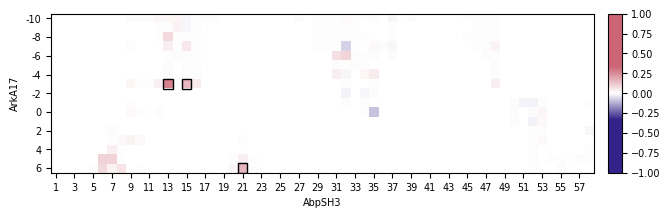

In [54]:
num_values = len(significant_rev) * len(significant_rev.columns) # following the Bonferroni Method
#sig_and_10 = np.array((significant < (0.05/num_values)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
#sig_and_10 = np.array((significant < (0.05/num_values)).values.tolist())
sig_and_10 = np.array((significant_rev < (0.05)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
coords = np.argwhere(sig_and_10)

map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
#fig, ax = difference.residue_contacts.plot(cmap = map_1)

fig, ax = plt.subplots()
im = plt.imshow(difference, cmap = map_1, vmin = -1, vmax = 1)
# 1. Get the current position of the plot in the figure
pos = ax.get_position()

# --- MISSING PIECE START ---
# Define the colorbar axes [left, bottom, width, height]
# pos.x1 + 0.02 puts it just to the right of the plot
# pos.y0 and pos.height ensure the vertical size matches exactly
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
# --- MISSING PIECE END ---

# Now this will work
cb = fig.colorbar(im, cax=cax)
cax.tick_params(labelsize=7)

# 2. Extract coordinates where mask is True
# Note: np.argwhere returns (row, col), but patches use (x, y) which is (col, row)

for row, col in coords:
    # Create a Rectangle patch
    # (col - 0.5, row - 0.5) aligns the box edges with the pixel edges
    rect = patches.Rectangle((col - 0.5, row - 0.5), 1, 1, 
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

#cb_ax = fig.axes[0]
#cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
#my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
#my_yticks = ['7','5','3', '1', '-1', '-3', '-5', '-7', '-9','-11'] # ArkA17 goes from K(6) to K(-10)
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
#current_yticks = np.linspace(0, 17, len(my_yticks))
my_yticks = ['6', '4', '2', '0', '-2', '-4', '-6', '-8', '-10'] # correct labelling
current_yticks = np.arange(0, 17, 2)

ax.set_xlabel("AbpSH3", fontsize = 7)
ax.set_ylabel("ArkA17", fontsize = 7)

my_xticks = []
current_xticks = []

# Loop through every single number in the range
for x in range(int(minA)-1, int(maxA)):
    # Check if the residue number is odd
    if x % 2 != 0:
        current_xticks.append(x - int(minA)) # The pixel position
        my_xticks.append(x)                  # The actual label

# Apply to the plot
ax.set_xticks(current_xticks)
ax.set_xticklabels(my_xticks, fontsize=7)
ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.invert_yaxis()
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('ArkA17_bound_contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()

In [55]:
difference

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
59,NaN,NaN,NaN,NaN,0.000042,0.084875,0.029792,0.054917,NaN,0.000875,...,NaN,NaN,NaN,0.000125,NaN,NaN,-0.000208,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,0.097958,0.094458,0.002208,NaN,NaN,...,NaN,NaN,NaN,0.000417,NaN,0.000292,0.000542,NaN,-0.000333,-0.00575
61,NaN,NaN,NaN,NaN,NaN,NaN,0.03375,0.000125,NaN,NaN,...,NaN,NaN,NaN,-0.000208,NaN,NaN,NaN,NaN,NaN,-0.000333
62,NaN,NaN,NaN,NaN,NaN,NaN,0.004125,0.008667,0.024667,0.012875,...,NaN,NaN,NaN,0.000125,0.009833,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,-0.004167,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000958,-0.000042,NaN,NaN,NaN,NaN,-0.011542
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.000083,NaN,-0.021417,0.013667,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012625,0.000125,...,NaN,-0.002583,NaN,-0.000625,0.016458,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000792,NaN,...,NaN,-0.002375,-0.017458,-0.018042,0.003917,NaN,NaN,NaN,NaN,0.000125
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021542,-0.000375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
avg_salt_contacts_list = []
for traj in range(len(traj_new_salt)):
    ind_df = ContactFrequency(traj_new_salt[traj]).residue_contacts.df.iloc[minB-1:maxB,minA-1:maxA]
    avg_salt_contacts = ind_df.sum().sum()
    avg_salt_contacts_list.append(avg_salt_contacts)

avg_no_salt_contacts_list = []
for traj in range(len(traj_no_salt_new)):
    ind_df = ContactFrequency(traj_no_salt_new[traj]).residue_contacts.df.iloc[minB-1:maxB,minA-1:maxA]
    avg_no_salt_contacts = ind_df.sum().sum()
    avg_no_salt_contacts_list.append(avg_no_salt_contacts)

# Combine avg contact data (TOTAL)
avg_contact_values = np.concatenate([avg_no_salt_contacts_list, avg_salt_contacts_list])

nsim = 10

#calculate the real difference, no salt minus salt
diff_total = np.array(avg_no_salt_contacts_list).mean() - np.array(avg_salt_contacts_list).mean()

print("Avg # total contacts no-salt minus salt difference = " , diff_total)

#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(avg_contact_values)
    diff_samples[sample] = (np.mean(random_groups[0:nsim]) 
             - np.mean(random_groups[nsim:nsim + nsim]))
    if diff_samples[sample] >= diff_total:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

Avg # total contacts no-salt minus salt difference =  1.4713750000000019
p-value =  0.00019998000199980003


In [57]:
np.array(avg_no_salt_contacts_list).mean()

30.260375

In [58]:
st.sem(np.array(avg_no_salt_contacts_list))

0.2289720423557325

In [59]:
np.array(avg_salt_contacts_list).mean()

28.788999999999998

In [60]:
st.sem(np.array(avg_salt_contacts_list))

0.26231544952924185